ML – MIDTERM EXAM (100 Marks)

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [59]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


#### Q1 Answer (Student)

_Write your calculations and explanation here. You may use Python below if you want, but final reasoning must be readable._

In [60]:
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]
data_q1

[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]

In [61]:
df = pd.DataFrame({"Monthly customer spending (in dollars)" : data_q1})
df

,Monthly customer spending (in dollars)
0,30
1,35
2,32
3,34
4,33
5,500
6,31
7,34
8,32
9,33


In [62]:
# Q1_1 - median
# given data = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]
# after it is sorted = [30, 31, 32, 32, 33, 33, 34, 34, 35, 500]
# n/2 = 10/2 = 5
# therefore = (33 + 33)/2 = 33

In [63]:
# Q1_1 - Median
median_value = df['Monthly customer spending (in dollars)'].median()
print(f"Median: {median_value}")

Median: 33.0


In [64]:
# Q1_1 - IQR
Q1 = df['Monthly customer spending (in dollars)'].quantile(0.25)
Q3 = df['Monthly customer spending (in dollars)'].quantile(0.75)

IQR = Q3 - Q1
print(f"Interquartile Range: {IQR}")

Interquartile Range: 2.0


In [65]:
# Q1_2
lower = Q1 - 1.5 * IQR
print(f"Lower Fence: {lower}")

upper = Q3 + 1.5 * IQR
print(f"Upper Fence {upper}")

outlier = df[ (df['Monthly customer spending (in dollars)'] < lower) | (df['Monthly customer spending (in dollars)'] > upper) ]
print(f"Outliers: {outlier}")
# since 500 > upper fence i.e. 37

Lower Fence: 29.0
Upper Fence 37.0
Outliers:    Monthly customer spending (in dollars)
5                                     500


In [66]:
# Q1_3
'''
using the IQR rule it can be come to the conclusin that 500 is an outlier. Thus, the presence of the outlier makes the distribution skewed. 
In such cases, median is the best measure since it is resistant to outliers i.e they are not influenced by extreme values. 
Contrary, using mean+standard deviation, they are affected by outliers which would give us a misleading spending. 
Mean and standard deviation assumes a more symmetrical distribution. 
'''

'\nusing the IQR rule it can be come to the conclusin that 500 is an outlier. Thus, the presence of the outlier makes the distribution skewed. \nIn such cases, median is the best measure since it is resistant to outliers i.e they are not influenced by extreme values. \nContrary, using mean+standard deviation, they are affected by outliers which would give us a misleading spending. \nMean and standard deviation assumes a more symmetrical distribution. \n'

### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.


#### Q2 Answer (Student)

_Write your step by step Bayes calculation and explanation here._

In [67]:
# q2_1

![q2_1](q2_1.jpeg)

In [68]:
'''
Q2_2
If prevalance i.e. p(d=+ve) increases to 20 percent, the positive predictive value (ppv) will increase. 
As per formula, we can see that positive predictive value (ppv) depends upon prior probability of disease p(d) along with true positive p(T=+ve|D=+ve)
and false positive rate p(T=+ve|D=-ve)=1-p(T=-ve|D=-ve). An increase to 20% prevalance implies more people within the populaiton having the disease
so positve test p(t=+ve) is more likely to come from truly sick person. An increase in prevalance also implies a decrease in healthy people which means
a decrease in false positive p(T=+ve|D=-ve) due to less healthy individuals in the community compared to true positives. 
Thus, with a high prevalance, positive test result is more reliable, which increases positive predictive value (ppv). 
'''

'\nQ2_2\nIf prevalance i.e. p(d=+ve) increases to 20 percent, the positive predictive value (ppv) will increase. \nAs per formula, we can see that positive predictive value (ppv) depends upon prior probability of disease p(d) along with true positive p(T=+ve|D=+ve)\nand false positive rate p(T=+ve|D=-ve)=1-p(T=-ve|D=-ve). An increase to 20% prevalance implies more people within the populaiton having the disease\nso positve test p(t=+ve) is more likely to come from truly sick person. An increase in prevalance also implies a decrease in healthy people which means\na decrease in false positive p(T=+ve|D=-ve) due to less healthy individuals in the community compared to true positives. \nThus, with a high prevalance, positive test result is more reliable, which increases positive predictive value (ppv). \n'

### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)

_Write your task type, preprocessing list, and pipeline paragraph here._

In [69]:
'''
Q3_1:
Binary Classification Task since the target is either 0 or 1 and not some continunous number.

Q3_2: 
- One Hot Encoding for region since this has 7 categorical levels.
- Standardization/Scaling for the numerical features.
- Binning for age and then converting it back to ordinal encoding.
- If any feature has missing values then imputing them. 
- Outlier detection and handling for the numerical features. 

Q3_3:
First and foremost, I would check for missing values and handle them respectively. Next, the dataset will be split into training and testing
sets using the desired ration. Then I would check the distribution of the dataset and impute
the missing values of numerical features using either mean or median according to the distribution of the dataset. For categorical 
values, the missing data points will be imputed using mode. After that, the numerical features of this dataset will be scaled using a scaler
and the categirical column (region) will be encoded using One Hot encoding. After that, the training set of the data will be used to train a classification model. 
After the model gets trained, it will be evaluated on testing dataset (which was split earlier). Furthermore, the model 
will be evalued on various evaluation metrics. To name a few, precision, recall, F1-Score and so on. Based on the results, the model
can be tuned further if desired accuracy metrics is not achieved. 
'''



'\nQ3_1:\nBinary Classification Task since the target is either 0 or 1 and not some continunous number.\n\nQ3_2: \n- One Hot Encoding for region since this has 7 categorical levels.\n- Standardization/Scaling for the numerical features.\n- Binning for age and then converting it back to ordinal encoding.\n- If any feature has missing values then imputing them. \n- Outlier detection and handling for the numerical features. \n\nQ3_3:\nFirst and foremost, I would check for missing values and handle them respectively. Next, the dataset will be split into training and testing\nsets using the desired ration. Then I would check the distribution of the dataset and impute\nthe missing values of numerical features using either mean or median according to the distribution of the dataset. For categorical \nvalues, the missing data points will be imputed using mode. After that, the numerical features of this dataset will be scaled using a scaler\nand the categirical column (region) will be encoded u

---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.


In [70]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

df

,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,NaN,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,NaN,south,9.0,0


In [71]:
# Q4_1a missing value summary
df.isnull().sum()
# feature age has 2 null values and purchases has 1 null value

age             2
region          0
purchases       1
premium_user    0
dtype: int64

In [72]:
# Q4_1b number of unique values per column
df.nunique()

age             5
region          4
purchases       6
premium_user    2
dtype: int64

In [73]:
# Q4_1c correlation among numerical columns
numeric_col = ['age', 'purchases']
target_col = ['premium_user'] 

In [74]:
corr_matrix = df[numeric_col + target_col].corr()
corr_matrix

,age,purchases,premium_user
age,1.000000,0.923677,0.789534
purchases,0.923677,1.000000,0.825860
premium_user,0.789534,0.825860,1.000000


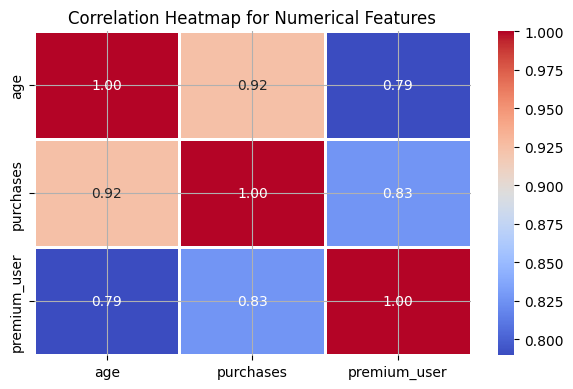

In [75]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

# the features age and purchase has high correlation between them. After that, purchase and premium user has moderate positive correlation. 
# Higher purchase and premium purchase may be linked. 
# premium_user and age has a lower correlation among all the features.  

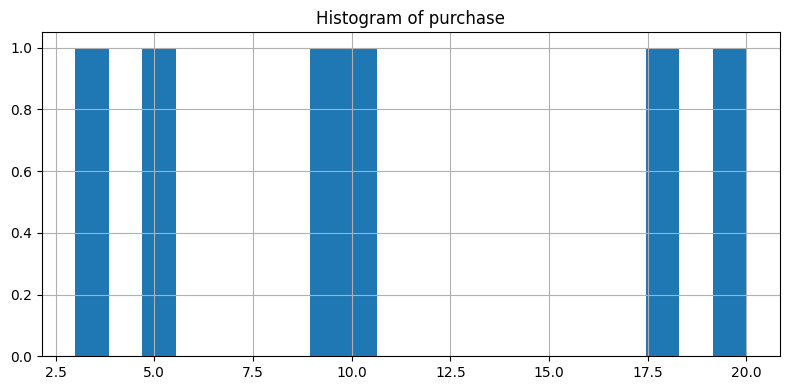

In [76]:
# Q4_1d_i Histogram of purchase
df['purchases'].hist(bins=20, figsize=(8, 4))
plt.title("Histogram of purchase")
plt.tight_layout()
plt.show()

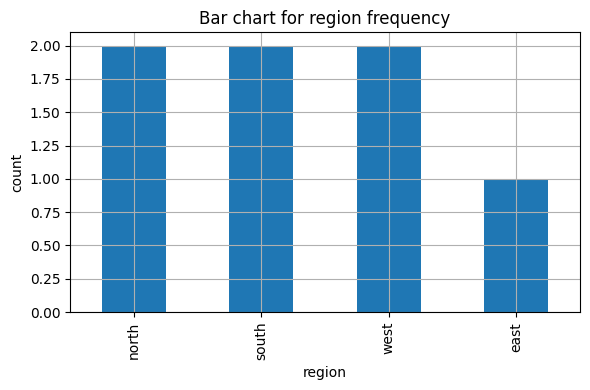

In [77]:
#4_1d_ii bar chart for region frequency
df['region'].value_counts().plot(kind='bar')
plt.title("Bar chart for region frequency")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# this signifies that within the dataset, east appered only once whereas north, south and west appeared twice

In [78]:
# q4_2a Imputing age with median
age_median = df['age'].median()
age_median

np.float64(30.0)

In [79]:
df['age'] = df['age'].fillna(age_median)
df['age']

0    25.0
1    30.0
2    30.0
3    22.0
4    45.0
5    52.0
6    30.0
Name: age, dtype: float64

In [80]:
# q4_2b imputing puchases with mean
purchases_mean = df['purchases'].mean()
print(f"purchases_mean: {purchases_mean}")

df['purchases'] = df['purchases'].fillna(purchases_mean)
df['purchases']

purchases_mean: 10.833333333333334


0     3.000000
1    10.000000
2     5.000000
3    10.833333
4    20.000000
5    18.000000
6     9.000000
Name: purchases, dtype: float64

In [81]:
# q4_2c encoding region using OHE
df = pd.get_dummies(df, columns=['region'], dtype=int)


In [82]:
df

,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,25.0,3.000000,0,0,1,0,0
1,30.0,10.000000,1,0,0,1,0
2,30.0,5.000000,0,0,1,0,0
3,22.0,10.833333,0,1,0,0,0
4,45.0,20.000000,1,0,0,0,1
5,52.0,18.000000,1,0,0,0,1
6,30.0,9.000000,0,0,0,1,0


In [83]:
# another domain driven feature using age
df['age_bin'] = pd.cut(
    df['age'], 
    bins=[20, 30, 50, 60], 
    labels=["Young", "Adult", "Senior"], 
)

In [84]:
# # q4_2d scaling all numeric columns using robust scaler
rc = RobustScaler()
df[numeric_col] = rc.fit_transform(df[numeric_col])
df

,age,purchases,premium_user,region_east,region_north,region_south,region_west,age_bin
0,-0.5,-0.943820,0,0,1,0,0,Young
1,0.0,0.000000,1,0,0,1,0,Young
2,0.0,-0.674157,0,0,1,0,0,Young
3,-0.8,0.112360,0,1,0,0,0,Young
4,1.5,1.348315,1,0,0,0,1,Adult
5,2.2,1.078652,1,0,0,0,1,Senior
6,0.0,-0.134831,0,0,0,1,0,Young


In [85]:
# # q4_2d scaling all numeric columns using robust scaler
# md = df[numeric_col].median()
# print(f"Median of Numeric Columns:\n{md}")

In [86]:
# Q1 = df[numeric_col].quantile(.25)
# print(f"Q1:\n{Q1}")

In [87]:
# Q3 = df[numeric_col].quantile(.75)
# print(f"Q3:\n{Q3}")

In [88]:
# IQR = Q3 - Q1
# print(f"IQR:\n{IQR}")

In [89]:
# df[numeric_col] = df[numeric_col]-md
# df[numeric_col]

In [90]:
# df[numeric_col] = df[numeric_col]/IQR
# df[numeric_col]

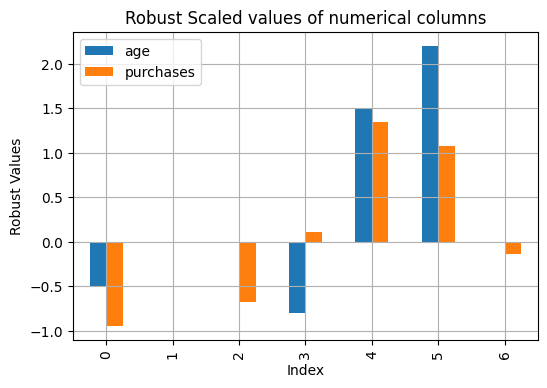

In [91]:
df[numeric_col].plot(kind='bar')
plt.title("Robust Scaled values of numerical columns")
plt.xlabel("Index")
plt.ylabel("Robust Values")
plt.show()

# age of index 5 potrays some outlier tendency.
# same for purchase index 3 and 6 which has very small values compared to rest of the values within that series. 

In [92]:
from sklearn.preprocessing import PolynomialFeatures

poly_cols = ['age', 'purchases']
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df[poly_cols])
poly_feature_names = poly.get_feature_names_out(poly_cols)
print(poly_feature_names)
print()
print(poly_features.shape)
print()
print(poly_features)

['age' 'purchases' 'age^2' 'age purchases' 'purchases^2']

(7, 5)

[[-0.5        -0.94382022  0.25        0.47191011  0.89079662]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.         -0.6741573   0.         -0.          0.45448807]
 [-0.8         0.11235955  0.64       -0.08988764  0.01262467]
 [ 1.5         1.34831461  2.25        2.02247191  1.81795228]
 [ 2.2         1.07865169  4.84        2.37303371  1.16348946]
 [ 0.         -0.13483146  0.         -0.          0.01817952]]


In [93]:
# Q4_3
high_spender = pd.DataFrame({
    "age^2"         : poly_features[:, 2], 
    "purchases^2"   : poly_features[:, 4],
    "age*purchases" : poly_features[:, 3],
})
high_spender
# This captures non-linear relationships between the two features. 

,age^2,purchases^2,age*purchases
0,0.25,0.890797,0.471910
1,0.00,0.000000,0.000000
2,0.00,0.454488,-0.000000
3,0.64,0.012625,-0.089888
4,2.25,1.817952,2.022472
5,4.84,1.163489,2.373034
6,0.00,0.018180,-0.000000


In [94]:
final = pd.concat([
    df,
    high_spender,
], axis=1)
final

,age,purchases,premium_user,region_east,region_north,region_south,region_west,age_bin,age^2,purchases^2,age*purchases
0,-0.5,-0.943820,0,0,1,0,0,Young,0.25,0.890797,0.471910
1,0.0,0.000000,1,0,0,1,0,Young,0.00,0.000000,0.000000
2,0.0,-0.674157,0,0,1,0,0,Young,0.00,0.454488,-0.000000
3,-0.8,0.112360,0,1,0,0,0,Young,0.64,0.012625,-0.089888
4,1.5,1.348315,1,0,0,0,1,Adult,2.25,1.817952,2.022472
5,2.2,1.078652,1,0,0,0,1,Senior,4.84,1.163489,2.373034
6,0.0,-0.134831,0,0,0,1,0,Young,0.00,0.018180,-0.000000


In [95]:
final['age_bin'] = final['age_bin'].map({
    'Young'  : 0, 
    'Adult'  : 1, 
    'Senior' : 2, 
})

In [96]:
# Q4_4
final

,age,purchases,premium_user,region_east,region_north,region_south,region_west,age_bin,age^2,purchases^2,age*purchases
0,-0.5,-0.943820,0,0,1,0,0,0,0.25,0.890797,0.471910
1,0.0,0.000000,1,0,0,1,0,0,0.00,0.000000,0.000000
2,0.0,-0.674157,0,0,1,0,0,0,0.00,0.454488,-0.000000
3,-0.8,0.112360,0,1,0,0,0,0,0.64,0.012625,-0.089888
4,1.5,1.348315,1,0,0,0,1,1,2.25,1.817952,2.022472
5,2.2,1.078652,1,0,0,0,1,2,4.84,1.163489,2.373034
6,0.0,-0.134831,0,0,0,1,0,0,0.00,0.018180,-0.000000


In [97]:
# final data frame consists of numerical columns scaled using robust scaling(except polynomial features), region and age_bin features encoded using OHE,
#  target column which is premium user
# and several domain driven features

_Use additional code cells below for EDA, preprocessing, feature engineering, and final dataframe. Add brief explanations in markdown between code blocks._

---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


In [98]:
# Q5_1 – Student Answer

# Step 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})

df2

,area_sqft,bedrooms,price
0,800,2,120
1,1000,2,150
2,1200,3,170
3,1500,3,210
4,1800,4,260
5,2000,4,300


In [99]:
# Q5_2
# splitting data set into 80% train and 20% test set i.e. 4 rows for training and 2 rows for test
X = df2[['area_sqft', 'bedrooms']]
y = df2['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [100]:
# Q5_3
# Fitting Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [101]:
# Q5_4
# Intercept, Coefficient, predictions from the test set
print(f"Coefficient m: {lr.coef_}")
print(f"Intercept c: {lr.intercept_}")

predicted_price = lr.predict(X_test)
print(f"Predicted price of the test set: {predicted_price}")

# model underfitting since predicted prices are lower than that of acutal prices

Coefficient m: [0.15384615 5.38461538]
Intercept c: -33.84615384615387
Predicted price of the test set: [100.         130.76923077]


In [102]:
X_test

,area_sqft,bedrooms
0,800,2
1,1000,2


In [103]:
y_test.to_frame()

,price
0,120
1,150


In [104]:
# Q5_5_a
# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, predicted_price)
print(f"Mean Absolute Error (MAE): {mae}")
# thus, the predicted house prices deviate from the actual house prices by  mae  on avg

Mean Absolute Error (MAE): 19.615384615384613


In [105]:
# Q5_5_b
# Root Mean Squared Error (RMSE)
mse = mean_squared_error(y_test, predicted_price)
print(f"Mean Squared Error (MSE): {mse}")

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")
# rmse pelalizes large errors more than mae

Mean Squared Error (MSE): 384.91124260355025
Root Mean Squared Error (RMSE): 19.61915499208746


In [106]:
# Q5_5_c
# R Squared
r2 = r2_score(y_test, predicted_price)
print(f"R Squared: {r2}")
# a negative r^2 signifies that the model's performance is worse than a mean prediction.

R Squared: -0.7107166337935567


In [107]:
residuals = y_test-predicted_price
print(f"Residuals:\n{residuals}")

Residuals:
0    20.000000
1    19.230769
Name: price, dtype: float64


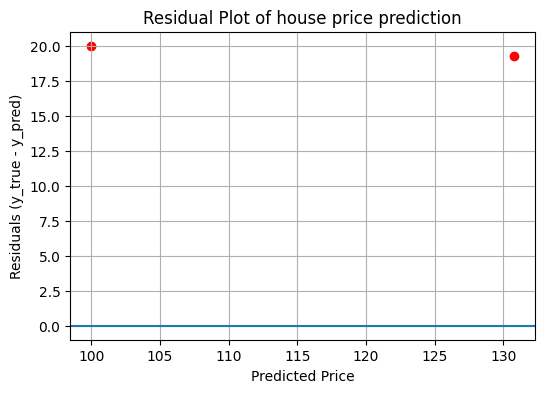

In [108]:
# Q5_6
# Residual Plot
plt.scatter(predicted_price, residuals, marker='o', color='red')
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residual Plot of house price prediction")
plt.show()

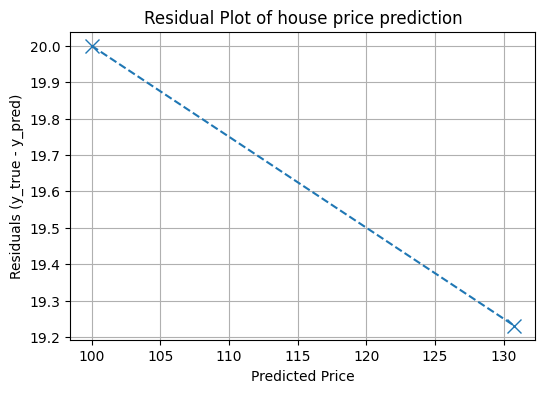

In [109]:
# Q5_6
# Residual Plot
plt.plot(predicted_price, residuals, marker='x', markersize='10', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residual Plot of house price prediction")
plt.show()

In [110]:
'''
The data set being small, the value of r^2 suggests that the model neither could generalise nor could perform well on the test set.
From the resiudual plot it can be clearly observed that as far as the first prediction is concerned, it has an error of 20. That is, the actual
value is supposed to be 120 but due to an error of 20 the predicted value is 100. Coming to the second point, it has an error/residual of 19.23076923
as shown by the vertical axis. Thus, the predicted value is 130.76923077 which in reality should have been 130.76923077+19.23076923=150.
It can be concluded that the model is making an approximate error of 20 points for each test data point which in an ideal scenarion, 
the residuals/errors should have been evenly distributed around 0.
'''

'\nThe data set being small, the value of r^2 suggests that the model neither could generalise nor could perform well on the test set.\nFrom the resiudual plot it can be clearly observed that as far as the first prediction is concerned, it has an error of 20. That is, the actual\nvalue is supposed to be 120 but due to an error of 20 the predicted value is 100. Coming to the second point, it has an error/residual of 19.23076923\nas shown by the vertical axis. Thus, the predicted value is 130.76923077 which in reality should have been 130.76923077+19.23076923=150.\nIt can be concluded that the model is making an approximate error of 20 points for each test data point which in an ideal scenarion, \nthe residuals/errors should have been evenly distributed around 0.\n'

_Use additional code cells below for train test split, model training, metrics, and the residual plot. Add a brief comment on the residuals in markdown._

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


In [111]:
# Q6 – Student Answer

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Write your code for threshold 0.5 and 0.3 below

In [112]:
y_pred_05 = np.where(y_prob >= 0.5, 1, 0)
print(f"Class Predictions with threshold 0.5: {y_pred_05}")

y_pred_03 = np.where(y_prob >= 0.3, 1, 0)
print(f"Class Predictions with threshold 0.3: {y_pred_03}")

Class Predictions with threshold 0.5: [1 0 1 0 1 0 1 0 1 0]
Class Predictions with threshold 0.3: [1 0 1 0 1 1 1 1 1 0]


In [113]:
def metrices (y, y_hat):
    
    cm = confusion_matrix(y, y_hat)
    print(f"Confusion Matrix:\n{cm}")

    prec = precision_score(y, y_hat)
    print(f"Precision: {prec}")

    rec = recall_score(y, y_hat)
    print(f"Recall: {rec}")

    f1 = f1_score(y, y_hat)
    print(f"F1 Score: {f1}")


In [114]:
# Q6_1_1
metrices(y_true, y_pred_05)

Confusion Matrix:
[[5 0]
 [0 5]]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [115]:
# Q6_1_2
metrices(y_true, y_pred_03)

Confusion Matrix:
[[3 2]
 [0 5]]
Precision: 0.7142857142857143
Recall: 1.0
F1 Score: 0.8333333333333334


In [116]:
# Q1_1_3
'''
By lowering the threshold, 

precision decreased as now model predicted more 1 where some of the ones weren't true i.e. false positives. 

Recall measures the number of actual postives that were correctly classified. In our case, changing threshold did not impact recall. It remained same
which signifies that in both cases, the actual positive data points were correctly classified as being positives. 

Likewise precision, F1 score also decreased. F1 score is the harmonic mean of precision and recall. 
f1 score = 2/((1/precision)+(1/recall)) = (2*precision*recall)/precision+recall
so, since precision dropped as discussed above, overall f1 score also decreased. 

To sum up, the model now catches more false positives as indicated by lower precision but at the same time recall remained unchanged at 1 and all actual
positives were already classified at threshold 0.5. As a result, lowering the threshold , recall remained unchanged but false positives increased which
reduced precision. 
'''

"\nBy lowering the threshold, \n\nprecision decreased as now model predicted more 1 where some of the ones weren't true i.e. false positives. \n\nRecall measures the number of actual postives that were correctly classified. In our case, changing threshold did not impact recall. It remained same\nwhich signifies that in both cases, the actual positive data points were correctly classified as being positives. \n\nLikewise precision, F1 score also decreased. F1 score is the harmonic mean of precision and recall. \nf1 score = 2/((1/precision)+(1/recall)) = (2*precision*recall)/precision+recall\nso, since precision dropped as discussed above, overall f1 score also decreased. \n\nTo sum up, the model now catches more false positives as indicated by lower precision but at the same time recall remained unchanged at 1 and all actual\npositives were already classified at threshold 0.5. As a result, lowering the threshold , recall remained unchanged but false positives increased which\nreduced pr

In [117]:
# Q6_2_4
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
print(f"False Positive Rates (FPR): {fpr}")
print(f"True Positive Rates (TPR): {tpr}")
print(f"Thresholds: {thresholds}")

False Positive Rates (FPR): [0. 0. 0. 1.]
True Positive Rates (TPR): [0.  0.2 1.  1. ]
Thresholds: [ inf 0.95 0.6  0.05]


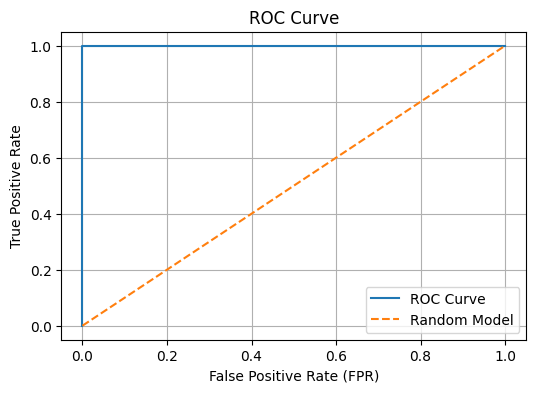

In [118]:
plt.figure()
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--', label="Random Model")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc='best')
plt.show()

In [119]:
# Q6_2_5
roc_auc = auc(fpr, tpr)
print(f"Area under the curve (AUC): {roc_auc: .3f}")

Area under the curve (AUC):  1.000


In [120]:
# Q6_2_6
'''
Here, we got a perfect AUC which is 1. This means that the model can perfectly classify between the two classes. 1.0 is a perfect classification performance.
'''

'\nHere, we got a perfect AUC which is 1. This means that the model can perfectly classify between the two classes. 1.0 is a perfect classification performance.\n'

In [121]:
# Q6_3_7
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
df3

,hours,passed
0,1,0
1,2,0
2,3,0
3,4,1
4,5,1
5,1,0
6,2,0
7,3,1
8,4,1
9,5,1


In [122]:
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(df3[['hours']], df3['passed'])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

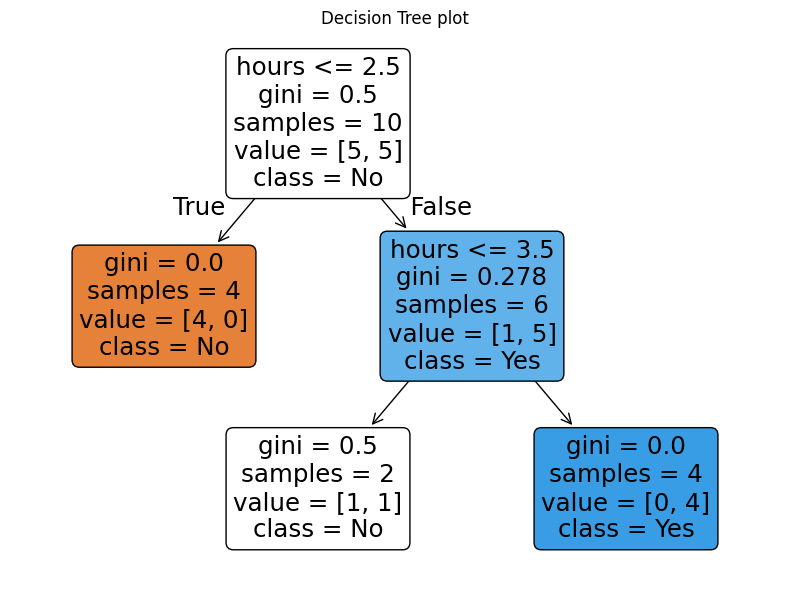

In [123]:
plt.figure(figsize=(8, 6))
plot_tree(
    tree, 
    feature_names=['hours'], 
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree plot")
plt.tight_layout()
plt.show()

In [124]:
#  Q6_3_9
'''
The data set is very small with only 10 samples and somewhat exhibits a clear pattern i.e. below 3 hours, everyone fails except 1.
From 4 hours, everyone passes. But, since the tree is small, and max depth is only 2, the chances of overfitting or memorizing the data points
is less. 
The tree may generalise well due to a clear pattern, although the dataset is small and simple. The tree generally overfits 
if it is very deep or if the max depth is large which in our situation is not really the case. 
'''

'\nThe data set is very small with only 10 samples and somewhat exhibits a clear pattern i.e. below 3 hours, everyone fails except 1.\nFrom 4 hours, everyone passes. But, since the tree is small, and max depth is only 2, the chances of overfitting or memorizing the data points\nis less. \nThe tree may generalise well due to a clear pattern, although the dataset is small and simple. The tree generally overfits \nif it is very deep or if the max depth is large which in our situation is not really the case. \n'

_Add more code cells for ROC and AUC, and for the decision tree on df3. Write your short explanations in markdown after the relevant outputs._